### References:
Symlib docs: https://web.stanford.edu/group/gfc/gfcsims/build/html/symlib_documentation.html#symlib.scale_factors

### TODO:

- Normalize by m200c
- Fit Diemer density profile
- Fit two power-law density profiles
- Charcterize BFE residuals 

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
plt.style.use("../../../visualizations/matplotlib.mplstyle")

In [5]:
import numpy as np

def diemer22_profile(x, alpha=0.15, beta=4.0, rs=0.2, rt=1.0):
    """
    Compute the dimensionless density profile from the Diemer (2022) model.

    This function evaluates the exponential density profile described in 
    Diemer (2022), which models the outer structure of dark matter halos.

    Parameters
    ----------
    x : array_like
        Dimensionless radius, typically defined as `r / r_200m` or another
        normalized radial coordinate. Must be positive.
    alpha : float, optional
        Inner slope transition parameter. Controls the curvature of the 
        inner profile. Typical values are around 0.15.
    beta : float, optional
        Outer steepening parameter. Controls how sharply the profile 
        steepens beyond the truncation radius. Default is 4.0.
    rs : float, optional
        Scale radius of the halo, defining the transition between the 
        inner and outer regions. Default is 0.2.
    rt : float, optional
        Truncation radius, typically associated with the splashback radius.
        Default is 1.0.

    Returns
    -------
    ndarray
        The dimensionless density profile evaluated at each radius `x`.

    Notes
    -----
    The function implements:

    .. math::
        S = -\\frac{2}{\\alpha}[(x/r_s)^\\alpha - 1] - 
            \\frac{1}{\\beta}[(x/r_t)^\\beta - (r_s/r_t)^\\beta]

        \\rho(x) \\propto e^{S}

    References
    ----------
    Diemer, B. (2023), MNRAS 519, 3292–3311
    """
    S = (
        -2.0 / alpha * ((x / rs) ** alpha - 1.0)
        - (1.0 / beta) * ((x / rt) ** beta - (rs / rt) ** beta)
    )
    return np.exp(S)

In [6]:
I = quad(diemer22_profile, 0, 1)[0]
print(I)

10.124157711068626


In [7]:
#np.mean(diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=0.2, rt=R))

In [8]:
diemer22_profile(0.2, alpha=0.15, beta=4.0, rs=0.2, rt=1)

np.float64(1.0)

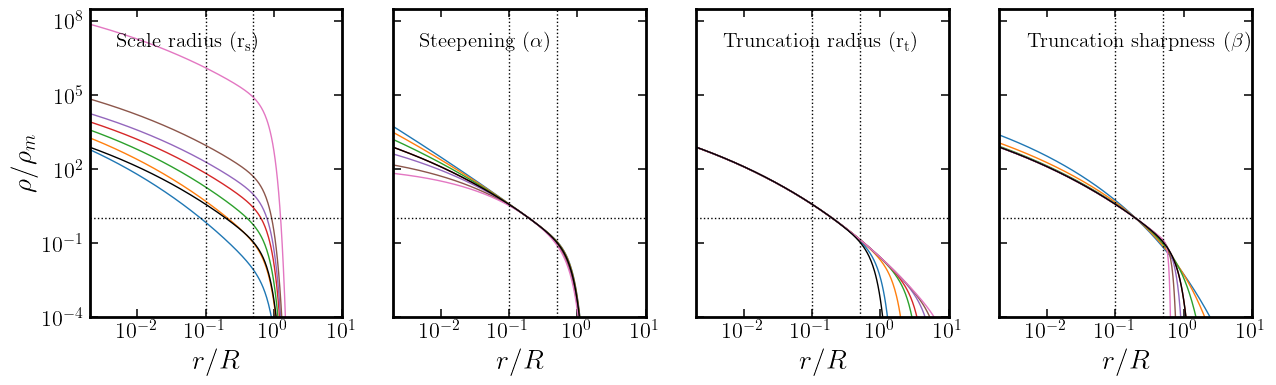

In [9]:
R=0.5
rbins = np.logspace(-8, np.log10(10*R), 1000)/R
rs_arr = np.array([0.02/R, 0.05/R, 0.1/R, 0.2/R, 0.3/R, 0.4/R, 0.6/R])
alpha_arr = np.array([0.03, 0.06, 0.1, 0.15, 0.2, 0.3, 0.4])
rt_arr = np.array([0.3/R, 0.5/R, 0.8/R, 1.0/R, 1.5/R, 2.0/R, 3/R])
beta_arr = np.array([0.5, 1, 2, 4, 6, 10, 20])
fig, ax = plt.subplots(1, 4, figsize=((15, 4)),sharey=True)

ax[0].text(5e-3, 1e7, r'$\rm{Scale\ radius\ } (r_s)$', fontsize=15)
for rs in range(len(rs_arr)):
    ax[0].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=rs_arr[rs], rt=R)/0.2, lw=1)

ax[1].text(5e-3, 1e7, r'$\rm{Steepening\ (\alpha)}$', fontsize=15)
for ais in range(len(alpha_arr)):
    ax[1].loglog(rbins, diemer22_profile(rbins, alpha=alpha_arr[ais], beta=4.0, rs=0.2, rt=R), lw=1)

ax[2].text(5e-3, 1e7, r'$\rm{Truncation\ radius\ } (r_t)$', fontsize=15)
for RT in range(len(rt_arr)):
    ax[2].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=0.2, rt=rt_arr[RT]), lw=1)

ax[3].text(5e-3, 1e7, r'$\rm{Truncation\ sharpness\ } (\beta)$', fontsize=15)
for B in range(len(beta_arr)):
    ax[3].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=beta_arr[B], rs=0.2, rt=R), lw=1)

for i in range(4):
    ax[i].loglog(rbins, diemer22_profile(rbins, alpha=0.15, beta=4.0, rs=0.2, rt=R), lw=1, c='k')


ax[0].set_ylim(1e-4, 3e8)
ax[0].set_ylabel(r'$\rho/\rho_m$')


for i in range(4):
    ax[i].set_xlabel(r'$r/R$')
    ax[i].set_xlim(2e-3, 10)
    ax[i].axvline(0.2*R, lw=1, ls=':', c='k')
    ax[i].axhline(1.0, lw=1, ls=':', c='k')
    ax[i].axvline(R, lw=1, ls=':', c='k')
    ax[i].set_xticks([0.01, 0.1, 1, 10])
    ax[i].set_yticks([1e-4, 1e-1, 1e2, 1e5, 1e8])

plt.show()

In [10]:
data = np.loadtxt("./halo_004_density_profile.txt")
data_smooth = np.loadtxt("./halo_004_density_profile_smooth.txt")

In [46]:
snap, time, z, rhocrit = np.loadtxt("./halo_004_parameters.txt", unpack=True)

In [47]:
#rhocrit * 1e10 / 

In [11]:
Mvir, Rvir = np.loadtxt("./halo_004_Mvir_Rvir.txt", unpack=True)

In [12]:
r200c = np.loadtxt("Halo004_r200c.txt")

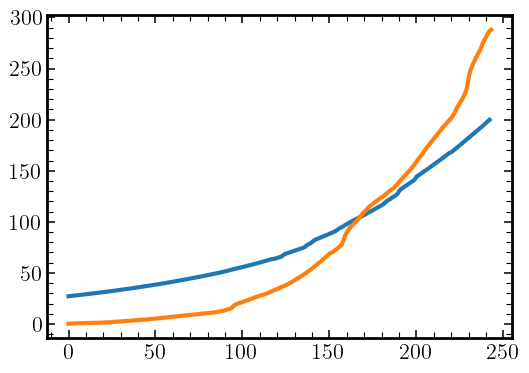

In [19]:
plt.plot(r200c**0.5)
plt.plot(Rvir)

In [21]:
edges = np.logspace(0.1, 2.5, 101)[:-1]

In [23]:
cmap = plt.cm.get_cmap('Blues')


/tmp/ipykernel_135010/2663837186.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')


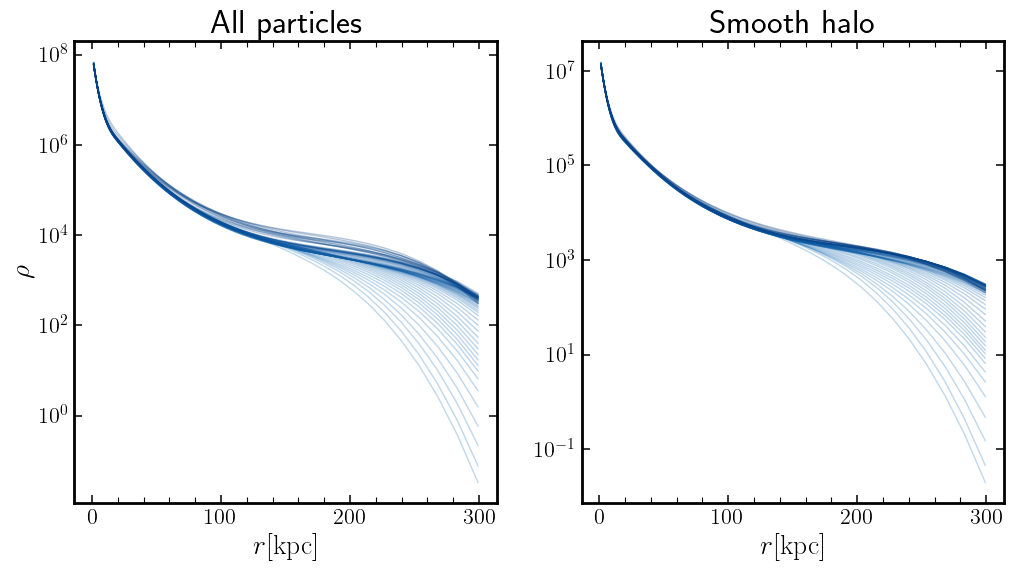

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i in range(0, 242):
    im = ax[0].semilogy(edges, data[i], c=cmap(i), alpha=0.3, lw=1)
    ax[1].semilogy(edges, data_smooth[i], c=cmap(i), alpha=0.3, lw=1)
ax[0].set_xlabel(r'$r\rm{ [kpc]}$')
ax[0].set_ylabel(r'$\rho$')
ax[1].set_xlabel(r'$r\rm{ [kpc]}$')
ax[0].set_title('All particles')
ax[1].set_title('Smooth halo')

plt.show()

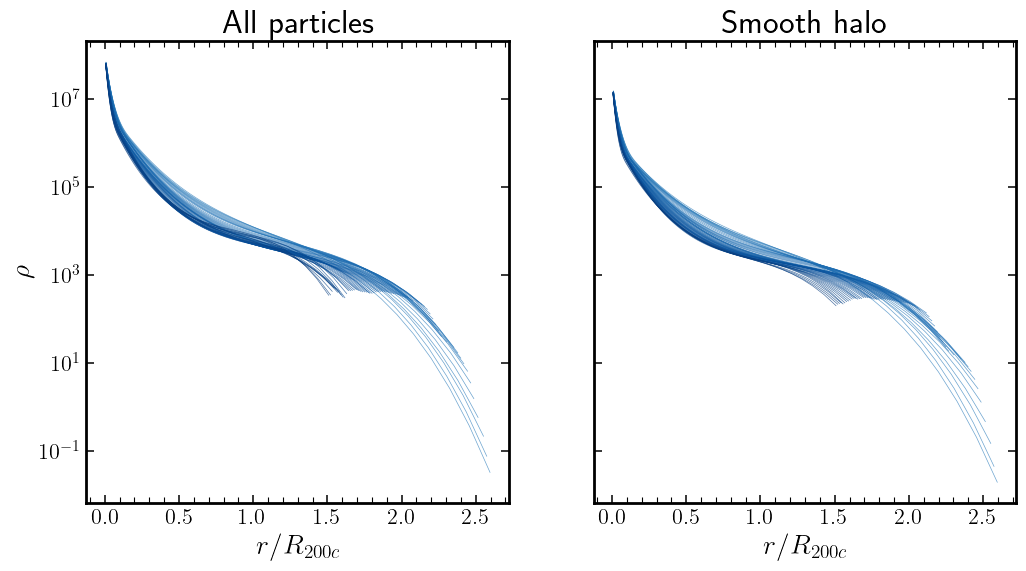

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i in range(242):
    ax[0].semilogy(edges/r200c[i]**0.5, data[i], c=cmap(i), alpha=0.7, lw=0.5)
    ax[1].semilogy(edges/r200c[i]**0.5, data_smooth[i], c=cmap(i), alpha=0.7, lw=0.5)
ax[1].set_xlabel(r'$r/R_{200c}$')
ax[0].set_xlabel(r'$r/R_{200c}$')

ax[0].set_ylabel(r'$\rho$')
ax[0].set_title('All particles')
ax[1].set_title('Smooth halo')
plt.show()


In [44]:
def fit_diemer22_profile(x_data, y_data, y_sigma=None, p0=None, bounds=None):
    """
    Fit the Diemer (2022) density profile to measured data using non-linear least squares.

    Parameters
    ----------
    x_data : array_like
        Array of dimensionless radius values at which the profile was measured.
    y_data : array_like
        Measured density (or dimensionless profile) corresponding to `x_data`.
    y_sigma : array_like, optional
        Uncertainties (1σ errors) of `y_data`. If provided, weighted least squares is used.
    p0 : sequence of floats, optional
        Initial guess for parameters `[alpha, beta, rs, rt]`.
        Default is `[0.15, 4.0, 0.2, 1.0]`.
    bounds : 2-tuple of array_like, optional
        Lower and upper bounds on parameters as required by `scipy.optimize.curve_fit`.
        Default bounds are:
        `([0.05, 1.0, 0.05, 0.3], [1.0, 10.0, 1.0, 3.0])`.

    Returns
    -------
    popt : ndarray
        Optimal parameter values `[alpha, beta, rs, rt]` that best fit the data.
    pcov : 2D ndarray
        Covariance matrix of the fitted parameters. The square roots of the diagonal 
        give the 1σ uncertainties.

   
    Examples
    --------
    >>> x = np.logspace(-2, 1, 50)
    >>> y_true = diemer22_profile(x, alpha=0.2, beta=4.0, rs=0.25, rt=1.1)
    >>> noise = 0.05 * np.random.normal(size=x.size)
    >>> y_meas = y_true * (1 + noise)
    >>> popt, pcov = fit_diemer22_profile(x, y_meas)
    >>> print("Best-fit parameters:", popt)
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    if p0 is None:
        p0 = [0.15, 4.0, 0.2, 1.0]

    if bounds is None:
        bounds = ([0.05, 1.0, 0.05, 0.3], [1.0, 10.0, 1.0, 3.0])

    # Perform the fit
    popt, pcov = curve_fit(
        diemer22_profile,
        x_data,
        y_data,
        sigma=y_sigma,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    return popt, pcov


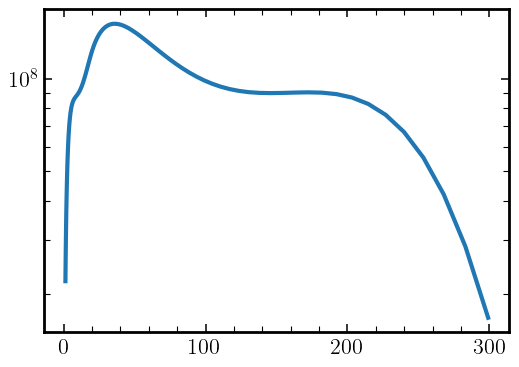

In [70]:
plt.semilogy(edges, edges**2*data_smooth[-1])

In [ ]:
fit_diemer22_profile(x_data=edges, y_data=data_smooth[-1])